# 0. Importing libraries:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

# 1. Introducing the data:

In [2]:
data = pd.read_csv('delivery_clean.csv')

data.shape

(451, 18)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              451 non-null    object 
 1   weekday           451 non-null    object 
 2   hour              451 non-null    int64  
 3   time_start        451 non-null    object 
 4   time_end          451 non-null    object 
 5   duration_minutes  451 non-null    int64  
 6   temp              451 non-null    float64
 7   fall              451 non-null    float64
 8   wind              451 non-null    float64
 9   bad_weather_flag  451 non-null    bool   
 10  basic             451 non-null    float64
 11  factor            451 non-null    float64
 12  tip               451 non-null    float64
 13  total             451 non-null    float64
 14  type              451 non-null    object 
 15  target            451 non-null    object 
 16  tar_sym           451 non-null    object 
 1

In [4]:
data.describe()

,hour,duration_minutes,temp,fall,wind,basic,factor,tip,total
count,451.000000,451.000000,451.000000,451.00000,451.000000,451.000000,451.000000,451.000000,451.000000
mean,13.110865,28.538803,7.442572,0.09133,1.631264,12.527051,2.063814,0.623570,13.150621
std,4.040478,9.622898,4.578462,0.29588,1.120802,3.473709,0.411386,2.104848,3.937753
min,7.000000,9.000000,-5.400000,0.00000,0.100000,6.780000,0.000000,0.000000,6.780000
25%,9.000000,22.000000,4.750000,0.00000,0.800000,9.890000,1.760000,0.000000,10.445000
50%,13.000000,28.000000,7.800000,0.00000,1.400000,11.850000,2.080000,0.000000,12.450000
75%,17.000000,34.000000,10.600000,0.03000,2.200000,14.685000,2.370000,0.000000,15.235000
max,21.000000,68.000000,18.700000,1.79000,7.500000,26.770000,2.940000,21.710000,30.710000


# 2. Distributions of data

2.1 Earnings

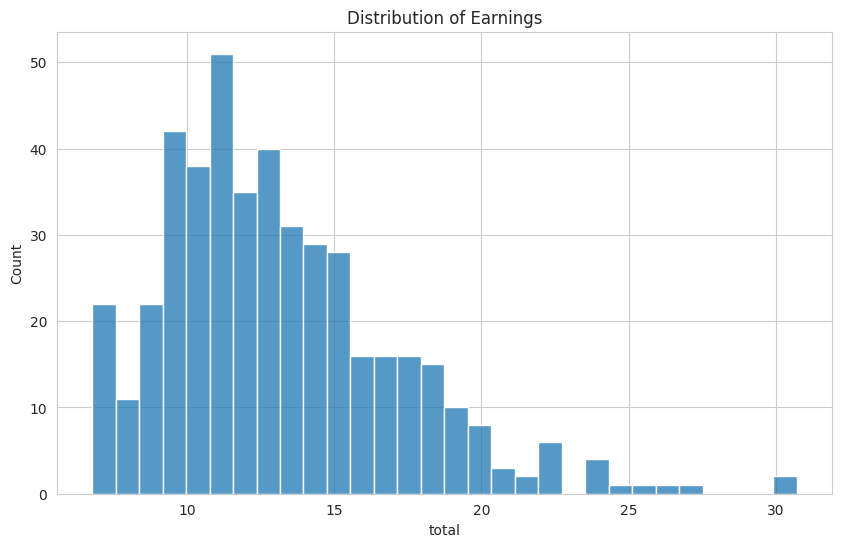

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(data["total"], bins=30)

plt.title("Distribution of Earnings")
plt.show()

The most orders were priced between 9 to 15 zlotys. The longer distance, the higher earn. Also the factor depending on traffic and weather can make the difference...

2.2 Tips

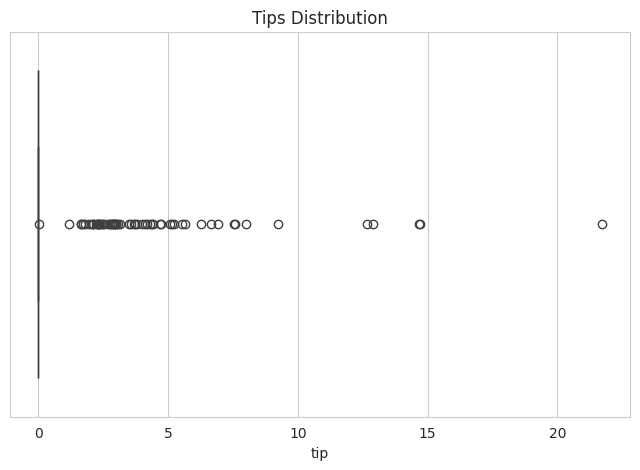

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data["tip"])

plt.title("Tips Distribution")
plt.show()

Mostly a few zlotys per an order given in the app.

2.3 Time analysis

In [ ]:
data['date'] = pd.to_datetime(data['date'] + ' ' + data['time_start'])
data["hour"] = data["date"].dt.hour

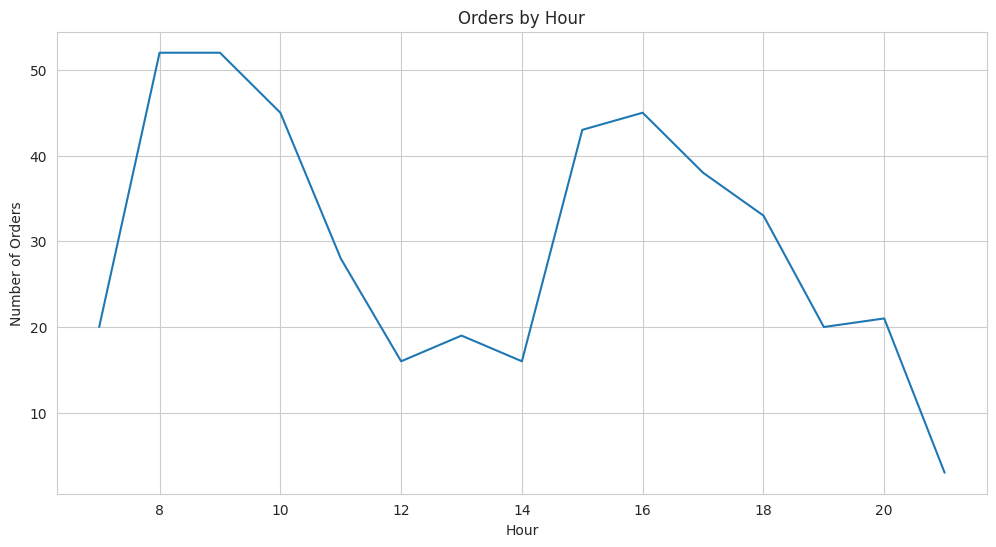

In [ ]:
data["hour"] = data["date"].dt.hour
hourly_orders = (
    data.groupby("hour")
      .size()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values
)

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()


The delivery app operates from 7 AM till 4 AM next day. Courier shifts were most frequently available during early morning and evening hours. Between 12 and 2 PM I usually had a lunch break after 3-4 hours of intensive ride. Afternoon and evening sessions typically offered higher multiplier factors and therefore higher earnings.

2.4 Earnings by hour

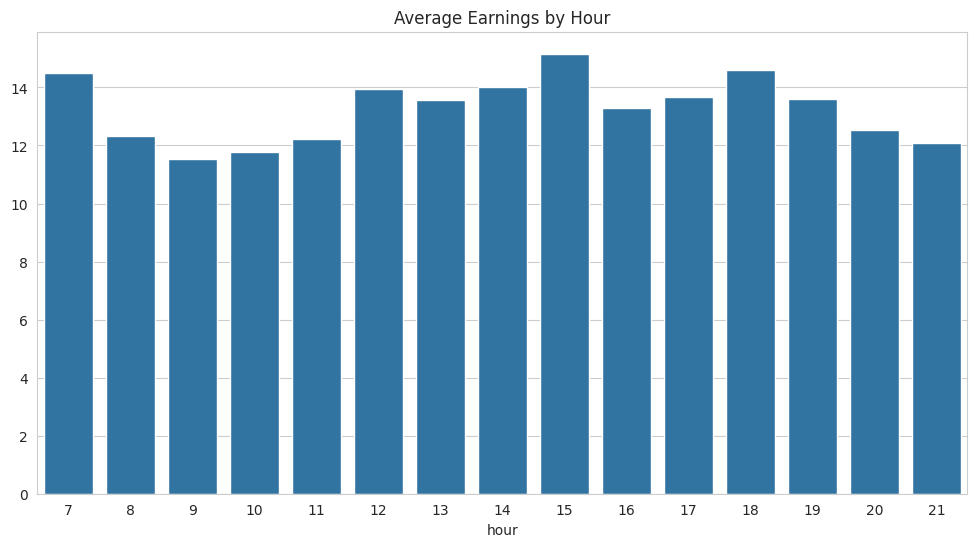

In [ ]:
data["hour"] = data["date"].dt.hour
hourly_earnings = (
    data.groupby("hour")["total"]
      .mean()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=hourly_earnings.index,
    y=hourly_earnings.values
)

plt.title("Average Earnings by Hour")
plt.show()


Although multiplier factors were relatively low at 7 AM, reduced courier availability increased the likelihood of receiving long-distance deliveries. Earnings increased gradually throughout the afternoon and peaked during evening hours.

2.5 Weekend vs working weekday

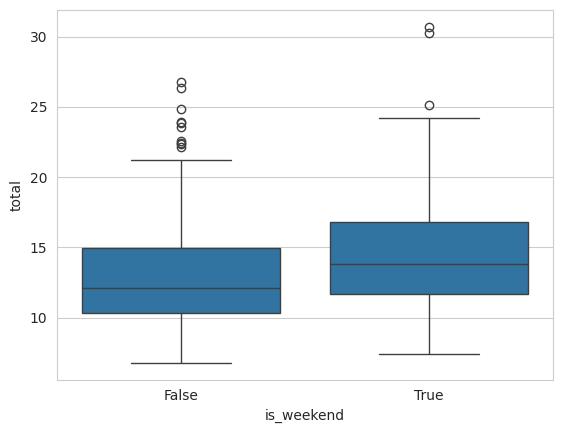

In [ ]:
sns.boxplot(
    data=data,
    x="is_weekend",
    y="total"
)

Weekend is more profitable than working weekdays.

# 3. Weather Analysis

3.1 Wind and duration minutes

<Axes: xlabel='wind', ylabel='duration_minutes'>

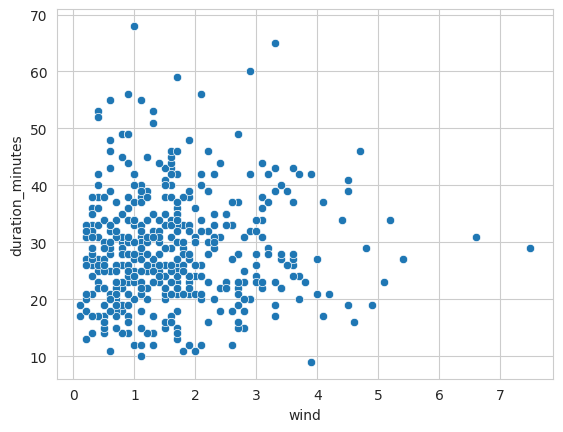

In [ ]:
sns.scatterplot(
    data=data,
    x="wind",
    y="duration_minutes"
)

The correlation is not clearly. There are much strong factors which determine the duration of delivery. For example waiting for the order in store/restaurant.

3.2 Weather vs tips

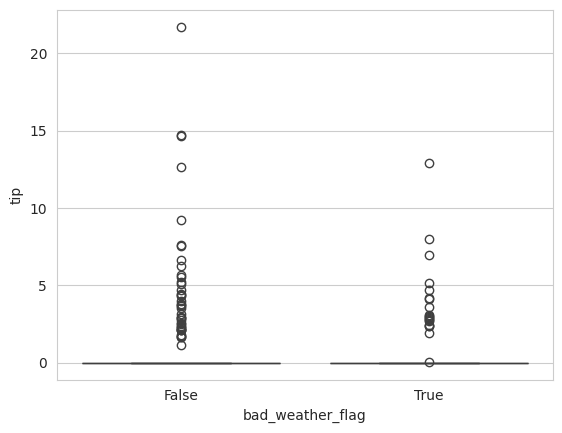

In [ ]:
sns.boxplot(
    data=data,
    x="bad_weather_flag",
    y="tip"
)

A higher average tip value was observed during favorable weather conditions. Further behavioral analysis would be required to explain this pattern.

3.3 Correlations

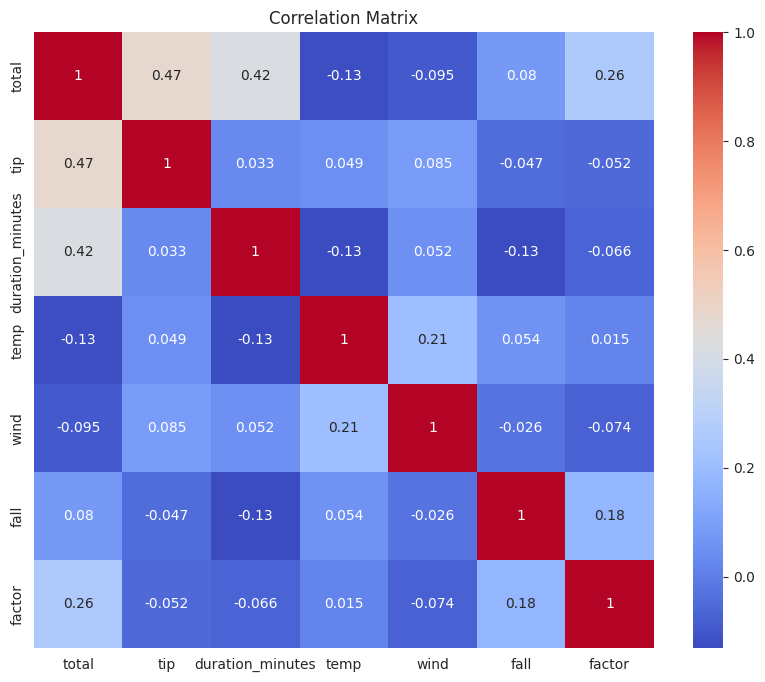

In [ ]:
numeric_cols = [
    "total",
    "tip",
    "duration_minutes",
    "temp",
    "wind",
    "fall",
    "factor"
]

corr = data[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The main driver of change in this dataset is the total variable, which exhibits the strongest (moderate) correlations with tip and duration. Weather factors have negligible or very weak influence on the financial and time variables.

# 4. Tips analysis

4.1 Tips vs total

<Axes: xlabel='total', ylabel='tip'>

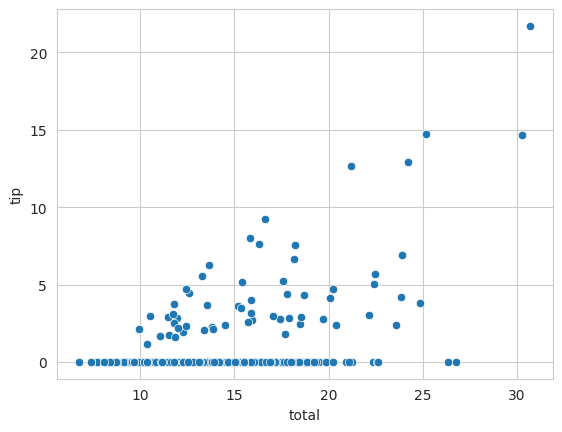

In [ ]:
sns.scatterplot(
    data=data,
    x="total",
    y="tip"
)

Tips rise the total earning

4.2 Tips by hour

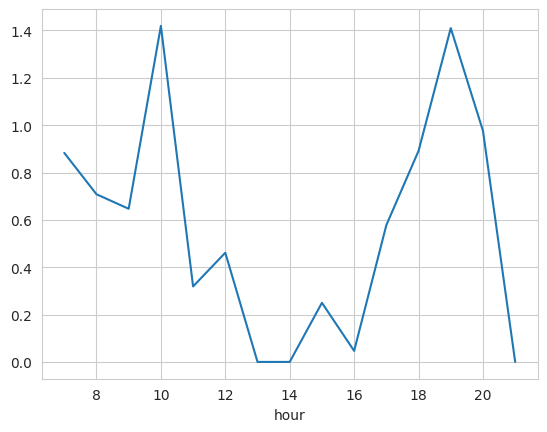

In [ ]:
tips_hour = (
    data.groupby("hour")["tip"]
      .mean()
)

sns.lineplot(
    x=tips_hour.index,
    y=tips_hour.values
)

Most tipped are the evening hours

# 5. Earnings per hour

In [ ]:
data["earnings_per_hour"] = (
    data["total"] /
    (data["duration_minutes"] / 60)
)

5.1 Weekends vs Working weekdays

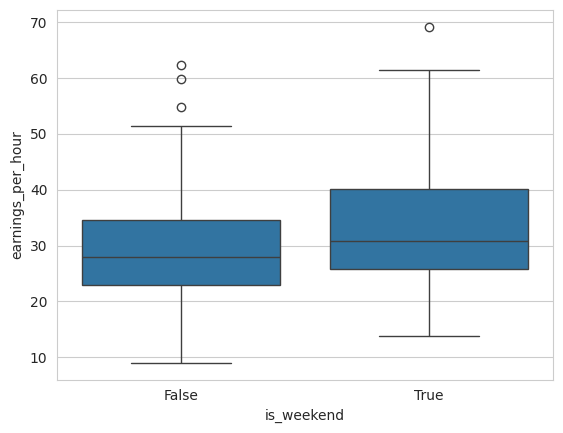

In [ ]:
sns.boxplot(
    data=data,
    x="is_weekend",
    y="earnings_per_hour"
)

5.2 Profitable hours

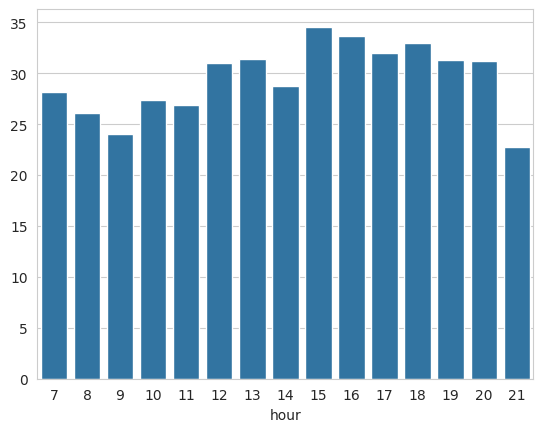

In [ ]:
profit_hour = (
    data.groupby("hour")["earnings_per_hour"]
      .mean()
)

sns.barplot(
    x=profit_hour.index,
    y=profit_hour.values
)


Late afternoon/early evening (3-8 PM) hours are most profitable. The decent earnings are also at noon (12-1 PM)

# 6. Geographic analysis

6.1 Average Delivery Duration by District

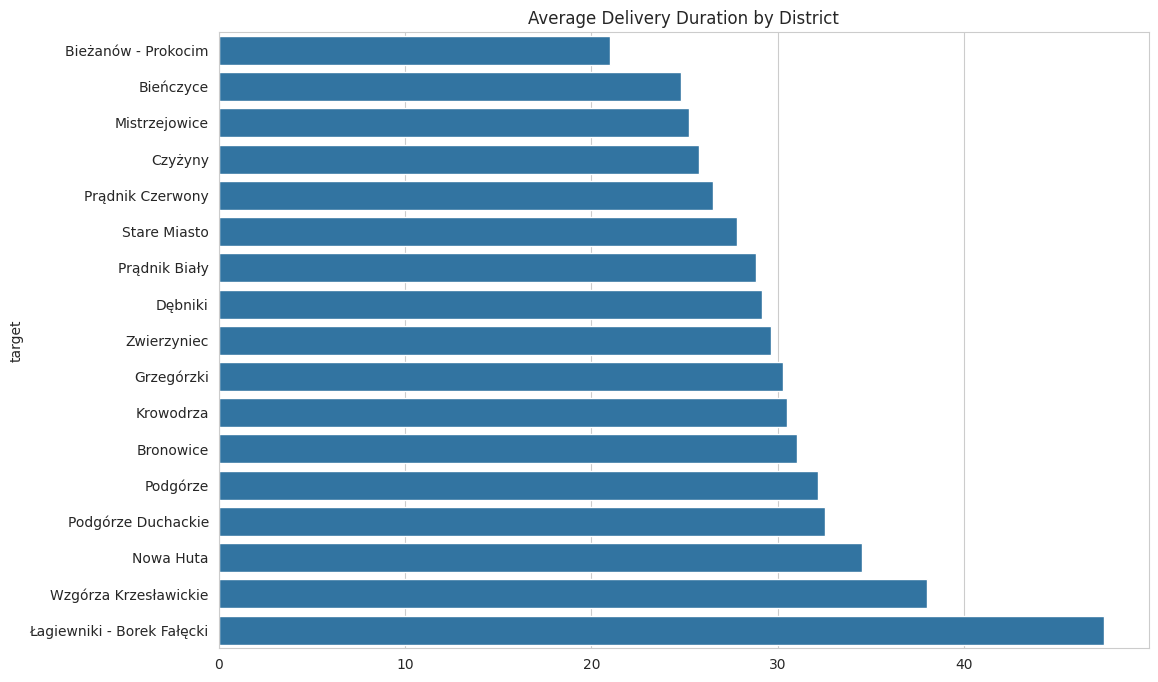

In [ ]:
district_duration = (
    data.groupby("target")["duration_minutes"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=district_duration.values,
    y=district_duration.index
)

plt.title("Average Delivery Duration by District")


I was in Podgórze district when the order to Bieżanów- Prokocim appeared. This likely contributed to the relatively short average delivery duration observed in that district.
The bicycle couriers have distance limit in their orders. Operating in Prądnik Czerwony increased the probability of receiving deliveries to nearby northern districts. Like on the map below. The ranges there are approximate.


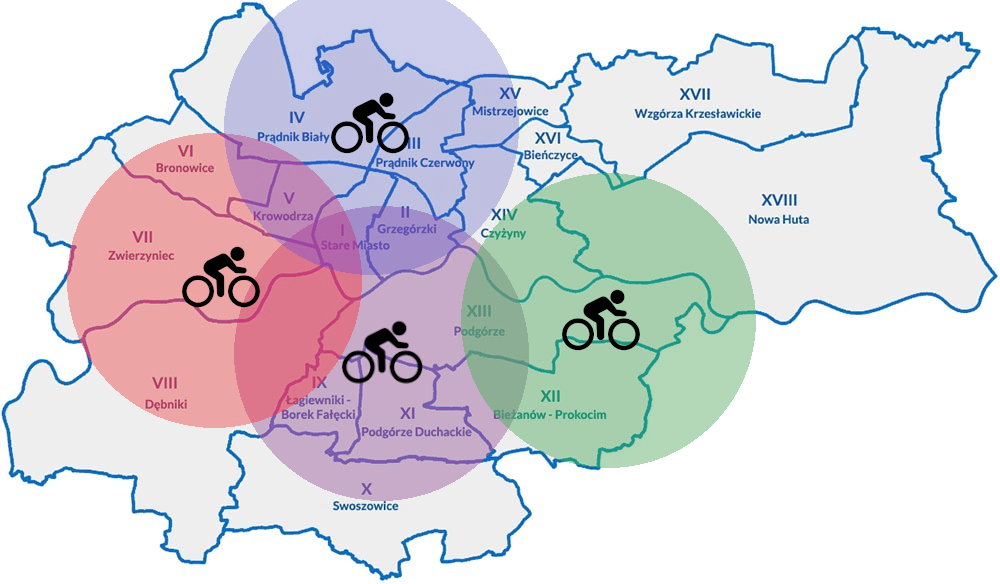

6.2 Average earnings by district

In [ ]:
df_earn = data.groupby('target')['total'].mean().reset_index(name='avg_earn')

print(df_earn.head())

                target   avg_earn
0            Bieńczyce  13.746000
1  Bieżanów - Prokocim  10.850000
2            Bronowice  12.640000
3              Czyżyny  12.899667
4              Dębniki  13.485000


<>:31: SyntaxWarning: invalid escape sequence '\w'
<>:31: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_2302/3239621636.py:31: SyntaxWarning: invalid escape sequence '\w'
  plt.savefig('\wykres.png', dpi=300)


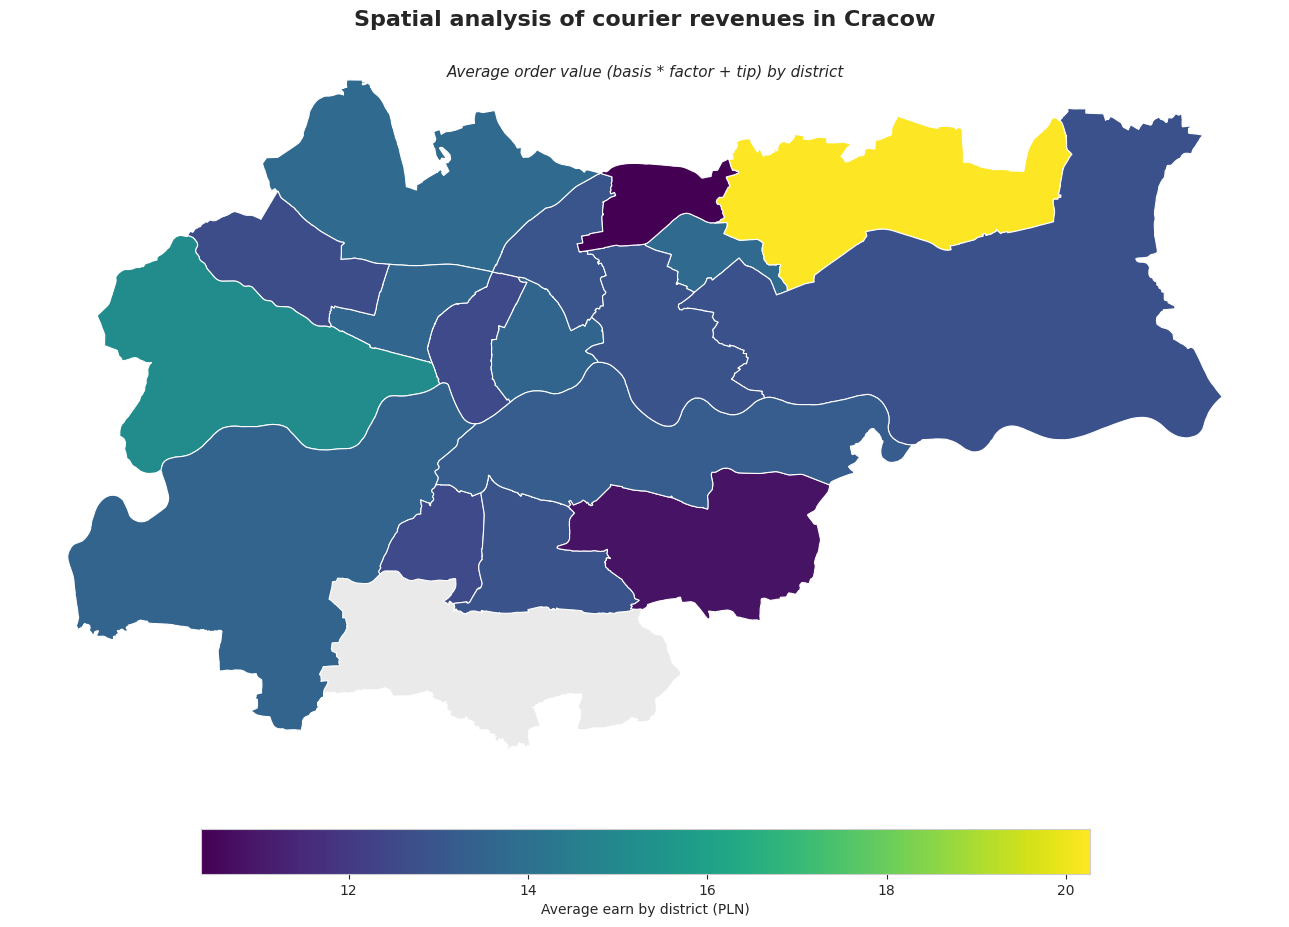

In [ ]:
import geopandas as gpd

df_earn = data.groupby(['target', 'tar_sym'])['total'].mean().reset_index(name='avg_earn')

map = gpd.read_file('Dzielnice.geojson')

map_earn = map.merge(df_earn, left_on='nr_dzielni', right_on='tar_sym', how='left')

fig, ax = plt.subplots(1, 1, figsize=(13, 10))
map_earn.plot(ax=ax, color='#eaeaea', edgecolor='white', linewidth=0.4)

map_earn.dropna(subset=['avg_earn']).plot(
    column='avg_earn',
    ax=ax,
    cmap='viridis',
    legend=True,
    edgecolor='white',
    linewidth=0.8,
    legend_kwds={
        'label': "Average earn by district (PLN)",
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.7
    }
)

ax.set_title("Spatial analysis of courier revenues in Cracow", fontsize=16, fontweight='bold', pad=15)
fig.suptitle("Average order value (basis * factor + tip) by district", fontsize=11, y=0.92, style='italic')

ax.axis('off')

plt.tight_layout()
plt.show()

The only link between earnings and localization is distance between courier and customer. As above- operating in one district increase the probability of receiving deliveries to nearby districts.

6.3 Dominant type of delivery by district

In [ ]:
df_counts = data.groupby(['target', 'type']).size().reset_index(name='count')
df_dominant = df_counts.loc[df_counts.groupby('target')['count'].idxmax()]

print(df_dominant.head())

                 target        type  count
0             Bieńczyce        deli      1
5   Bieżanów - Prokocim  vietnamese      1
6             Bronowice   fast food      4
12              Czyżyny   groceries     12
23              Dębniki   groceries      3


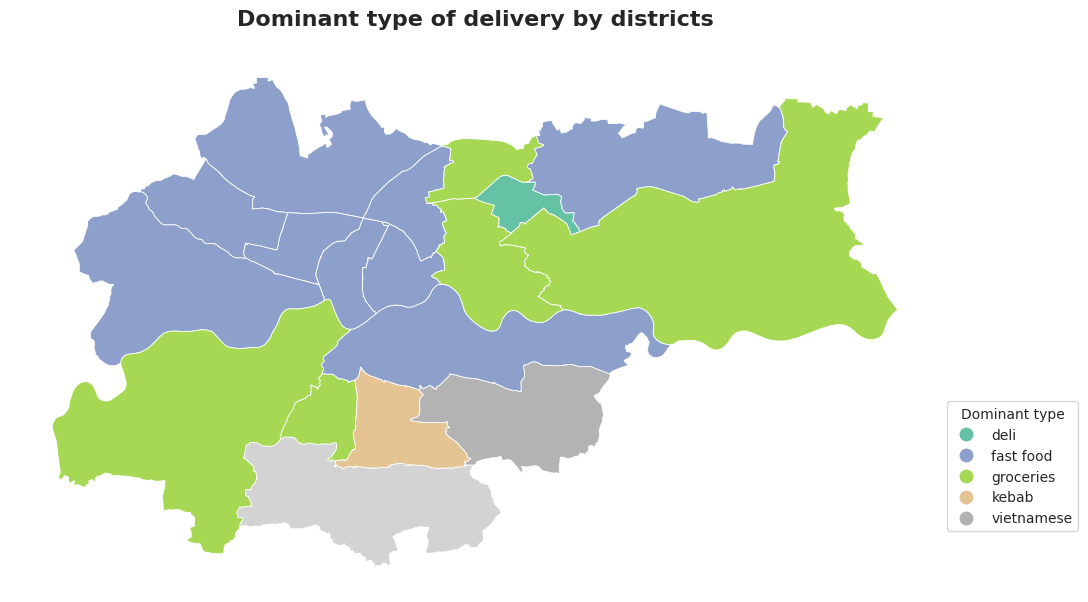

In [ ]:
import geopandas as gpd

df_counts = data.groupby(['target', 'tar_sym', 'type']).size().reset_index(name='count')
df_dominant = df_counts.loc[df_counts.groupby('target')['count'].idxmax()]

map = gpd.read_file('Dzielnice.geojson')

map_dominant = map.merge(df_dominant, left_on='nr_dzielni', right_on='tar_sym', how='left')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
map_dominant.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.4)
map_dominant.dropna(subset=['type']).plot(
    column='type',
    ax=ax,
    legend=True,
    categorical=True,
    cmap='Set2',
    edgecolor='white',
    linewidth=0.6,
    legend_kwds={'title': "Dominant type", 'loc': 'lower left', 'bbox_to_anchor': (1, 0.1)}
)

ax.set_title("Dominant type of delivery by districts", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')


The big fast food chains introduce many coupons to use in delivery apps. So, in near half of the city dominant type of delivery is fast food dishes. In the distant parts of the city groceries are ordered the most.  

# 7. The Outliers

7.1 Longest deliveries

In [ ]:
data.sort_values(
    by="duration_minutes",
    ascending=False
).head()

,date,weekday,time_start,time_end,duration_minutes,part_of_day,temp,fall,wind,bad_weather_flag,basic,factor,tip,total,type,target,is_weekend,hour,earnings_per_hour
272,2026-03-03,Tuesday,08:42:00,09:50:00,68,MOR,7.1,0.00,1.0,False,10.20,1.65,0.00,10.20,pharma,Podgórze,False,0,9.000000
149,2026-02-14,Saturday,17:56:00,19:01:00,65,ANO,0.7,0.12,3.3,True,16.83,2.80,0.00,16.83,korean,Podgórze,True,0,15.535385
198,2026-02-19,Thursday,13:50:00,14:50:00,60,NOON,-0.1,0.00,2.9,True,14.41,2.23,0.00,14.41,groceries,Prądnik Biały,False,0,14.410000
130,2026-02-13,Friday,10:20:00,11:19:00,59,MOR,9.8,0.00,1.7,False,12.68,1.83,0.00,12.68,groceries,Prądnik Biały,False,0,12.894915
102,2025-12-14,Sunday,09:43:00,10:39:00,56,MOR,4.0,0.00,2.1,False,15.60,1.53,14.68,30.28,animal goods,Prądnik Biały,True,0,32.442857


The longest was a double order from the pharmacy. I had to deliver the closer one firstly. And then the second one, some kilometers away..


7.2 Big tips

In [ ]:
data.sort_values(
    by="tip",
    ascending=False
).head()

,date,weekday,time_start,time_end,duration_minutes,part_of_day,temp,fall,wind,bad_weather_flag,basic,factor,tip,total,type,target,is_weekend,hour,earnings_per_hour
413,2026-04-26,Sunday,19:05:00,19:35:00,30,EVE,8.7,0.00,2.0,False,9.00,2.26,21.71,30.71,groceries,Prądnik Biały,True,0,61.420000
343,2026-03-15,Sunday,18:45:00,19:13:00,28,EVE,13.7,0.00,3.6,False,10.45,2.24,14.70,25.15,italian,Prądnik Biały,True,0,53.892857
102,2025-12-14,Sunday,09:43:00,10:39:00,56,MOR,4.0,0.00,2.1,False,15.60,1.53,14.68,30.28,animal goods,Prądnik Biały,True,0,32.442857
141,2026-02-14,Saturday,10:55:00,11:16:00,21,MOR,4.4,0.08,1.5,True,11.32,1.98,12.90,24.22,polish,Grzegórzki,True,0,69.200000
181,2026-02-18,Wednesday,10:33:00,11:03:00,30,MOR,2.7,0.00,2.0,False,8.54,1.73,12.65,21.19,breakfast,Podgórze,False,0,42.380000


That was nice, I've received such a big tip for an order I was waiting for long in the store!

# 8. Business insights


1.   Evening deliveries generate the highest earnings per hour despite longer average delivery duration.
2.   Wind speed shows stronger correlation with delivery duration than rainfall.
3.   Weekend orders produce higher average tips.